<a href="https://colab.research.google.com/github/fabri-marques/cv-coursework/blob/main/avv/visao_computacional_avv_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade V: Análise global, local e de textura em mini dataset próprio
*Por* **Fabricia Cristina Marques Jung**

Visão Computacional, Residência em TIC43. Unidade 3, Capítulo 2.

## Objetivo e Enunciado

#### Objetivo

Analisar tecnicamente o mini dataset já construído nas atividades anteriores e observar como
diferentes representações da imagem ajudam ou falham na distinção entre as duas classes. O
trabalho percorre três níveis complementares:

1. Nível global: histogramas de intensidade e cor, e estatística da imagem.
2. Nível local: pontos de interesse, descritores ORB e correspondência entre imagens.
3. Nível de textura: descritores baseados em relações espaciais e padrões locais (GLCM e LBP).

Em cada etapa a pergunta de fundo é sempre a mesma: o que este descritor preserva e o que ele perde?

#### Enunciado

Reutilizar o mini dataset criado anteriormente (2 classes, 10 imagens originais) e investigar
como cada estratégia de representação se comporta diante de variações reais de captura como
iluminação, distância, ângulo, resolução, compressão, textura e cor predominante. Ao final,
produzir uma conclusão técnica respondendo qual representação foi a mais adequada para este
dataset e por quê. Todo o desenvolvimento é feito neste notebook, com código acompanhado de
interpretação em markdown.

## Configuração do ambiente


In [ ]:
try:
    import google.colab  # noqa: F401
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

import os

if EM_COLAB and not os.path.exists('/content/cv-coursework'):
    !git clone https://github.com/fabri-marques/cv-coursework.git
    !pip -q install scikit-image scikit-learn


def localizar_dataset():
    candidatos = [
        '/content/cv-coursework/dataset',
        'dataset',
        '../dataset',
        '../../dataset',
    ]
    for c in candidatos:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError('Pasta dataset não encontrada.')


import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, blob_log, corner_peaks
from skimage.color import label2rgb

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

DATASET_PATH = localizar_dataset()
CLASSES = ['concha', 'pedra']
print('Dataset em:', DATASET_PATH)


def carregar_rgb(path):
    img = ImageOps.exif_transpose(Image.open(path))
    return np.array(img.convert('RGB'))


def carregar_gray(path):
    return cv2.cvtColor(carregar_rgb(path), cv2.COLOR_RGB2GRAY)


def reduzir(img, lado_max=1024):
    h, w = img.shape[:2]
    escala = lado_max / max(h, w)
    if escala < 1:
        img = cv2.resize(img, (int(w * escala), int(h * escala)),
                         interpolation=cv2.INTER_AREA)
    return img


def caminho(classe, n):
    return os.path.join(DATASET_PATH, classe, f'IMG_{n:03d}_original.jpg')


def listar(classe):
    return sorted(glob.glob(os.path.join(DATASET_PATH, classe, '*.jpg')))


arquivos = {c: listar(c) for c in CLASSES}
for c in CLASSES:
    print(f'{c}: {len(arquivos[c])} imagens')

Dataset em: /Users/marques/cv-coursework/dataset
concha: 5 imagens
pedra: 5 imagens


## Parte 1: Preparação do dataset e hipótese inicial

### 1.1 As duas classes

O mini dataset tem duas classes de objetos naturais fotografados com o celular, cinco imagens
cada, dez no total:

* **Concha** (classe A): conchas marinhas com a superfície marcada por costelas radiais bem
  visíveis. A forma é de leque e o relevo é o traço mais característico.
* **Pedra** (classe B): seixos lisos de tonalidade avermelhada, formato arredondado e superfície
  granular fina, sem relevo marcante.

As fotos foram tiradas em condições variadas de propósito: fundos diferentes (mão, tecido,
madeira, fundo escuro), iluminação que vai de bem clara a quase contra-luz, e distâncias
diferentes. Essa variação é justamente o que gera complexidade para os descritores, compativel com o mundo real.

### 1.2 Estrutura de pastas

A organização segue a das atividades anteriores, uma pasta por classe dentro de `dataset`:

In [ ]:
print('dataset/')
for c in CLASSES:
    print(f'  {c}/')
    for p in arquivos[c]:
        print(f'    {os.path.basename(p)}')

dataset/
  concha/
    IMG_001_original.jpg
    IMG_002_original.jpg
    IMG_003_original.jpg
    IMG_004_original.jpg
    IMG_005_original.jpg
  pedra/
    IMG_001_original.jpg
    IMG_002_original.jpg
    IMG_003_original.jpg
    IMG_004_original.jpg
    IMG_005_original.jpg


### 1.3 Amostra das classes

Duas imagens de cada classe, escolhidas para mostrar tanto o objeto quanto a variação de fundo e
iluminação dentro da mesma classe:

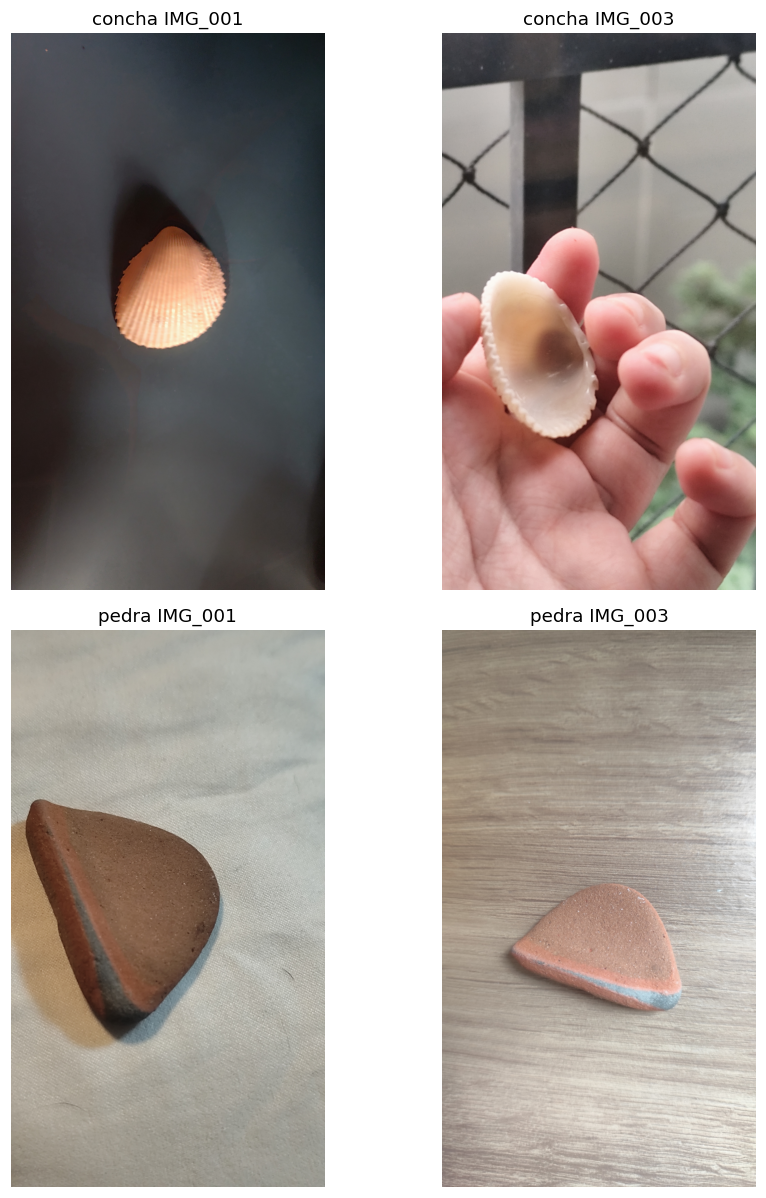

In [ ]:
amostra = {
    'concha': [1, 3],
    'pedra': [1, 3],
}

fig, axes = plt.subplots(2, 2, figsize=(9, 11))
for lin, c in enumerate(CLASSES):
    for col, n in enumerate(amostra[c]):
        img = reduzir(carregar_rgb(caminho(c, n)))
        axes[lin, col].imshow(img)
        axes[lin, col].set_title(f'{c} IMG_{n:03d}')
        axes[lin, col].axis('off')
plt.tight_layout()
plt.show()

### 1.4 Condições de aquisição imagem a imagem

Antes de medir qualquer coisa, registro as condições de captura de cada uma das dez imagens. Isso
é o que permite, depois, separar o que é propriedade do objeto do que é efeito da aquisição. O
brilho médio é medido na imagem em tons de cinza; fundo, iluminação e enquadramento vêm da
inspeção visual.

In [ ]:
aquisicao = pd.DataFrame([
    ['concha', 'IMG_001', 'fundo escuro liso', 'baixa, lateral, sombra forte', 'objeto centralizado'],
    ['concha', 'IMG_002', 'tecido claro', 'alta e difusa', 'close, leve desfoque'],
    ['concha', 'IMG_003', 'alambrado e vegetacao', 'luz de dia', 'segurada na mao'],
    ['concha', 'IMG_004', 'madeira clara', 'alta', 'objeto sobre a mesa'],
    ['concha', 'IMG_005', 'madeira clara', 'alta', 'costelas bem marcadas'],
    ['pedra', 'IMG_001', 'tecido claro', 'luz de dia', 'objeto sobre o tecido'],
    ['pedra', 'IMG_002', 'tecido claro', 'luz de dia', 'objeto sobre o tecido'],
    ['pedra', 'IMG_003', 'madeira clara', 'luz de dia', 'objeto sobre a mesa'],
    ['pedra', 'IMG_004', 'alambrado', 'luz de dia', 'segurada na mao'],
    ['pedra', 'IMG_005', 'cinza-azulado com sombra', 'baixa, lateral', 'objeto centralizado'],
], columns=['classe', 'imagem', 'fundo', 'iluminacao', 'enquadramento'])

brilho = {os.path.basename(p).replace('_original.jpg', ''): round(carregar_gray(p).mean(), 1)
          for c in CLASSES for p in arquivos[c]}
aquisicao['brilho_medio'] = aquisicao['imagem'].map(brilho)
aquisicao

,classe,imagem,fundo,iluminacao,enquadramento,brilho_medio
0,concha,IMG_001,fundo escuro liso,"baixa, lateral, sombra forte",objeto centralizado,155.3
1,concha,IMG_002,tecido claro,alta e difusa,"close, leve desfoque",159.2
2,concha,IMG_003,alambrado e vegetacao,luz de dia,segurada na mao,167.4
3,concha,IMG_004,madeira clara,alta,objeto sobre a mesa,150.8
4,concha,IMG_005,madeira clara,alta,costelas bem marcadas,94.0
5,pedra,IMG_001,tecido claro,luz de dia,objeto sobre o tecido,155.3
6,pedra,IMG_002,tecido claro,luz de dia,objeto sobre o tecido,159.2
7,pedra,IMG_003,madeira clara,luz de dia,objeto sobre a mesa,167.4
8,pedra,IMG_004,alambrado,luz de dia,segurada na mao,150.8
9,pedra,IMG_005,cinza-azulado com sombra,"baixa, lateral",objeto centralizado,94.0


A tabela já antecipa o problema central deste dataset: o fundo muda de imagem para imagem (escuro,
tecido, madeira, alambrado) e o brilho médio acompanha a iluminação e o fundo, não o objeto. As
duas conchas diferem muito entre si, essa variação intra classe causada pela aquisição é o pano de fundo de toda a análise
global que vem a seguir.

### 1.5 Hipótese inicial

**Fatores de aquisição que devem influenciar a análise.** O fundo muda de imagem para imagem e
costuma ocupar boa parte do quadro, então qualquer medida calculada sobre a imagem inteira mistura
objeto e fundo. A iluminação varia bastante, o que desloca o brilho médio e a posição do
histograma. Distância e ângulo mudam o tamanho aparente do objeto e a orientação das costelas da
concha. Resolução e compressão afetam principalmente os detalhes finos, que são o que distingue a
textura das duas classes.

**Diferenças visuais esperadas entre as classes.** A concha tem costelas radiais regulares, ou
seja, bordas internas fortes e repetitivas. A pedra é lisa, com microvariações suaves e nenhum
padrão geométrico. As cores se sobrepõem: as duas classes são de tons quentes (bege, rosado,
marrom avermelhado), então a cor sozinha provavelmente não separa bem.

**Descritor que aposto antes do experimento.** Como o que melhor diferencia concha de pedra é o
relevo da superfície e não a cor ou o brilho global, a expectativa é que os descritores **locais**
(cantos e ORB) e os de **textura** (GLCM e LBP) sejam mais úteis que os globais. Os histogramas e
a estatística da imagem inteira devem ser fracos aqui, porque são dominados pelo fundo e pela
iluminação, que variam dentro de cada classe.

## Parte 2: Análise global, histogramas e estatística

### 2.1 Estatística global das 10 imagens

Para cada imagem em tons de cinza calculo média, variância, desvio padrão e entropia de Shannon.
A média resume o brilho, a variância e o desvio padrão medem o contraste, e a entropia mede a
quantidade de informação, ou seja, o quanto o histograma está espalhado.

In [ ]:
registros = []
for c in CLASSES:
    for p in arquivos[c]:
        g = carregar_gray(p)
        registros.append({
            'classe': c,
            'imagem': os.path.basename(p).replace('_original.jpg', ''),
            'media': g.mean(),
            'variancia': g.var(),
            'desvio_padrao': g.std(),
            'entropia': shannon_entropy(g),
        })

tabela = pd.DataFrame(registros)
tabela_fmt = tabela.copy()
for col in ['media', 'variancia', 'desvio_padrao', 'entropia']:
    tabela_fmt[col] = tabela_fmt[col].round(2)
tabela_fmt

,classe,imagem,media,variancia,desvio_padrao,entropia
0,concha,IMG_001,70.80,1118.88,33.45,6.54
1,concha,IMG_002,154.29,210.05,14.49,5.64
2,concha,IMG_003,138.78,2268.17,47.63,7.43
3,concha,IMG_004,153.92,778.48,27.90,6.71
4,concha,IMG_005,133.34,999.18,31.61,6.91
5,pedra,IMG_001,155.30,1264.94,35.57,6.67
6,pedra,IMG_002,159.24,1851.94,43.03,6.62
7,pedra,IMG_003,167.38,862.08,29.36,6.83
8,pedra,IMG_004,150.85,1769.82,42.07,7.33
9,pedra,IMG_005,93.98,802.29,28.32,6.76


In [ ]:
resumo = tabela.groupby('classe')[['media', 'variancia', 'desvio_padrao', 'entropia']].mean().round(2)
print('Média de cada métrica por classe:')
resumo

Média de cada métrica por classe:


,media,variancia,desvio_padrao,entropia
classe,,,,
concha,130.23,1074.95,31.02,6.65
pedra,145.35,1310.21,35.67,6.84


**Leitura da tabela.** Os valores se sobrepõem fortemente entre as classes. O brilho médio da
concha vai de cerca de 71 a 154 e o da pedra de cerca de 94 a 167, ou seja, faixas que quase
coincidem. Dentro da própria classe concha a variação é enorme: a IMG_001, fotografada sobre
fundo escuro, tem média perto de 71, enquanto a IMG_002, bem iluminada, passa de 150. Isso mostra
que a média global está medindo a cena, principalmente o fundo e a luz, e não o objeto. A entropia
fica concentrada entre 5,6 e 7,4 sem separar as classes. A conclusão parcial é que a estatística
global, sozinha, não distingue concha de pedra: ela preserva o brilho e o contraste gerais da
cena, mas perde tudo que é específico do objeto.

Para não confiar só no olho, quantifico a separabilidade de cada métrica global com uma razão no
estilo de Fisher: a distância entre as médias das duas classes dividida pela soma dos desvios
dentro de cada classe. Quanto maior o valor, melhor a métrica separa as classes. Valores abaixo de
1 indicam que a dispersão interna engole a diferença entre classes.

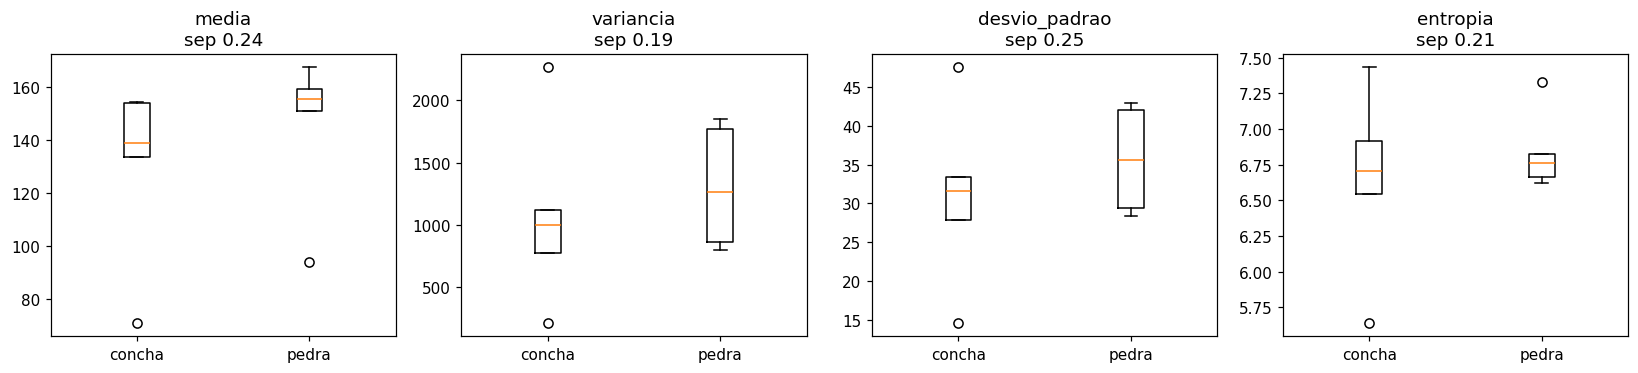

,metrica,separabilidade
0,media,0.237
1,variancia,0.189
2,desvio_padrao,0.248
3,entropia,0.205


In [ ]:
def separabilidade(col):
    a = tabela[tabela.classe == 'concha'][col]
    b = tabela[tabela.classe == 'pedra'][col]
    return abs(a.mean() - b.mean()) / (a.std() + b.std() + 1e-9)


sep = pd.DataFrame({
    'metrica': ['media', 'variancia', 'desvio_padrao', 'entropia'],
}).assign(separabilidade=lambda d: d['metrica'].map(lambda m: round(separabilidade(m), 3)))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, m in zip(axes, ['media', 'variancia', 'desvio_padrao', 'entropia']):
    dados = [tabela[tabela.classe == c][m].values for c in CLASSES]
    ax.boxplot(dados, labels=CLASSES)
    ax.set_title(f'{m}\nsep {separabilidade(m):.2f}')
plt.tight_layout()
plt.show()

sep

**O que a separabilidade mostra.** As quatro métricas globais ficam com razão de separação baixa,
abaixo de 1 em todos os casos, e os boxplots das duas classes se sobrepõem bastante. Em números, a
estatística global não distingue concha de pedra. Esse é o critério objetivo que sustenta a
conclusão de que os descritores globais são fracos para este dataset, e serve de linha de base
contra a qual os descritores locais e de textura serão comparados.

### 2.2 Histogramas de intensidade e de cor

Histogramas de intensidade (tons de cinza) para duas imagens de cada classe:

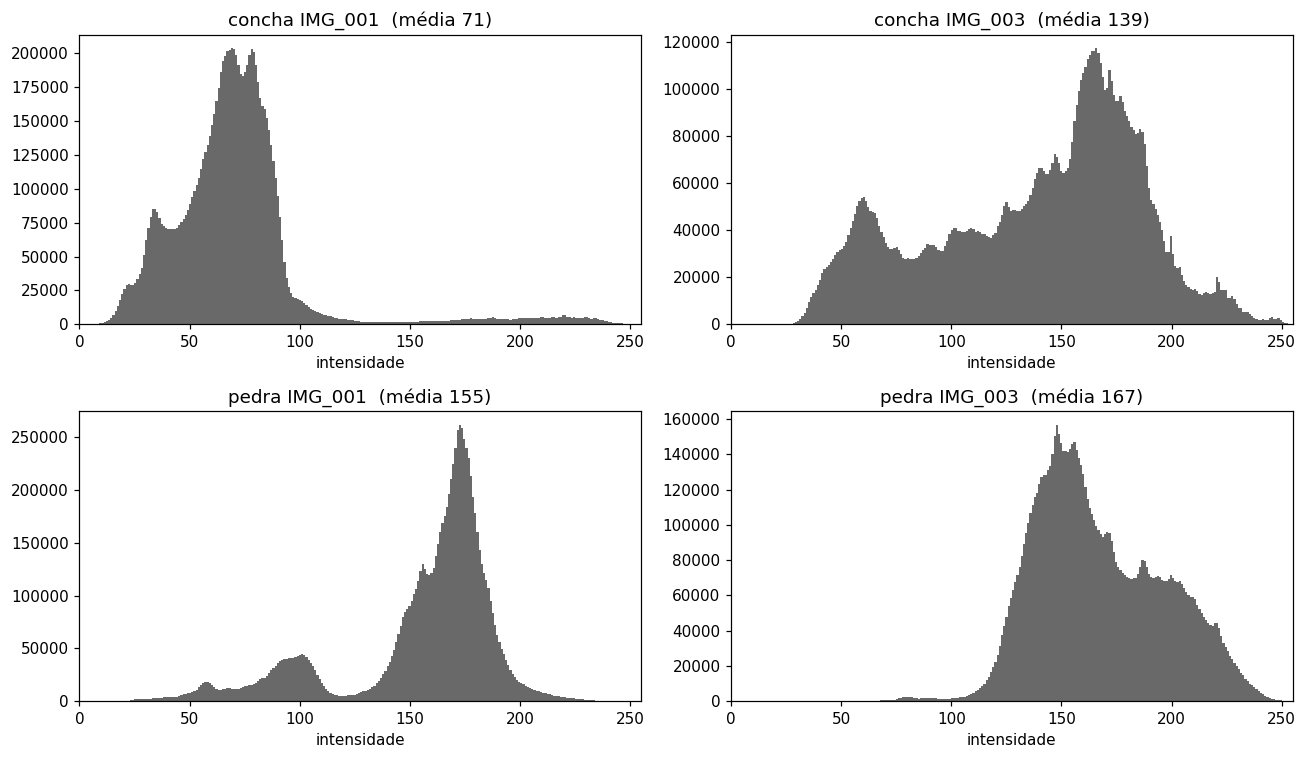

In [ ]:
sel = {'concha': [1, 3], 'pedra': [1, 3]}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for lin, c in enumerate(CLASSES):
    for col, n in enumerate(sel[c]):
        g = carregar_gray(caminho(c, n))
        axes[lin, col].hist(g.ravel(), bins=256, range=(0, 255), color='dimgray')
        axes[lin, col].set_title(f'{c} IMG_{n:03d}  (média {g.mean():.0f})')
        axes[lin, col].set_xlim(0, 255)
        axes[lin, col].set_xlabel('intensidade')
plt.tight_layout()
plt.show()

Histogramas de cor por canal RGB para as mesmas imagens:

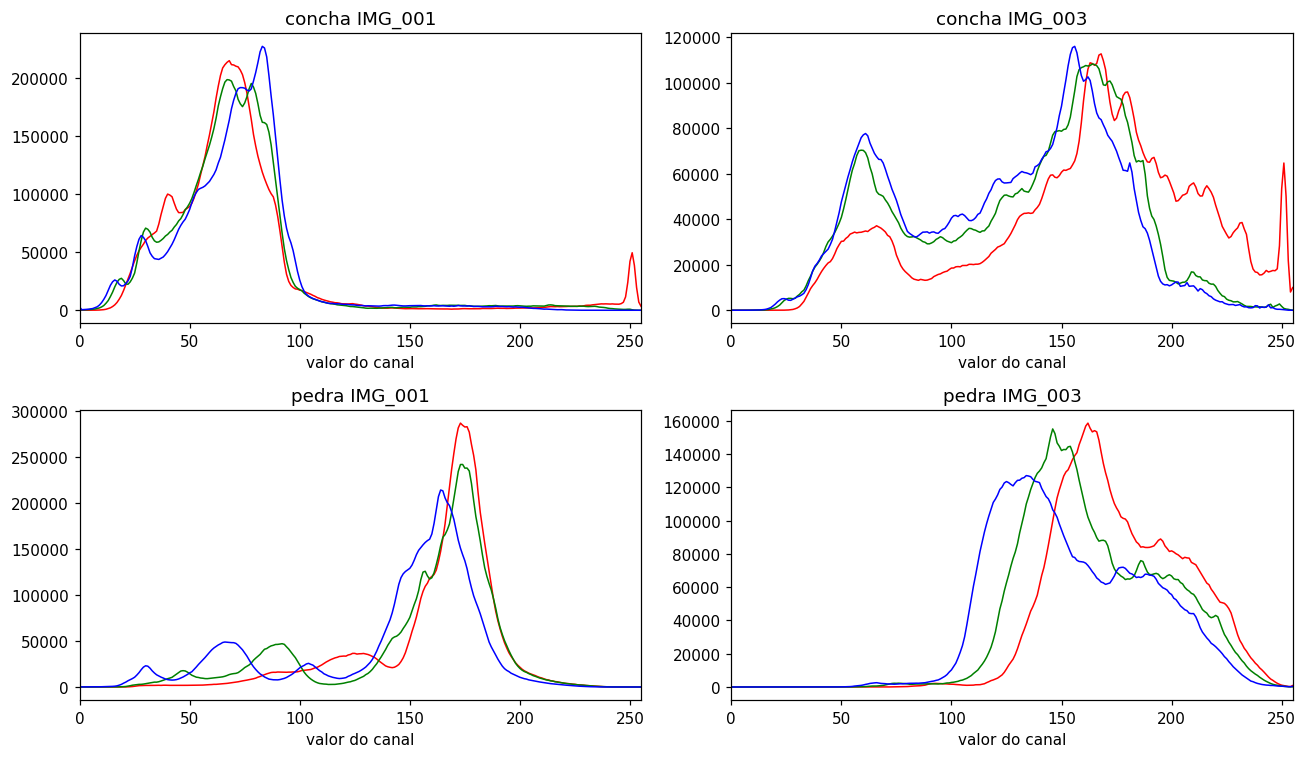

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
cores = ('red', 'green', 'blue')
for lin, c in enumerate(CLASSES):
    for col, n in enumerate(sel[c]):
        rgb = carregar_rgb(caminho(c, n))
        for k, cor in enumerate(cores):
            h = cv2.calcHist([rgb], [k], None, [256], [0, 256])
            axes[lin, col].plot(h, color=cor, linewidth=1)
        axes[lin, col].set_title(f'{c} IMG_{n:03d}')
        axes[lin, col].set_xlim(0, 255)
        axes[lin, col].set_xlabel('valor do canal')
plt.tight_layout()
plt.show()

**Onde os pixels se concentram.** As imagens sobre fundo claro (concha IMG_003, pedra IMG_001 e
IMG_003) concentram pixels nos tons médios e claros, com um pico alto à direita que é o fundo. A
concha IMG_001, sobre fundo escuro, tem uma massa grande de pixels escuros e um segundo grupo
menor nos tons claros, que é a própria concha. Ou seja, a posição do histograma é determinada
principalmente pelo fundo.

**Canal de cor dominante.** Em quase todas as imagens o canal vermelho fica acima do verde e do
azul, coerente com os tons quentes dos dois objetos. Existe dominância do vermelho, mas ela
aparece nas duas classes, então não serve para separá-las.

**Comportamento dentro da mesma classe.** Não é consistente. As duas conchas têm histogramas bem
diferentes entre si por causa do fundo e da luz, e o mesmo vale para as pedras. A variação intra
classe causada pela aquisição é maior que a variação entre classes.

**O histograma ajudou a separar as classes?** Não de forma confiável. Ele preserva brilho,
contraste e o tom quente geral, mas perde a forma e o relevo, que são justamente o que diferencia
concha de pedra. Isso confirma a hipótese de que os descritores globais seriam fracos para este
dataset.

### 2.3 Relação com a tarefa anterior: original contra versão derivada

Para uma imagem de cada classe gero duas versões derivadas no estilo das atividades anteriores:
uma com resolução reduzida e recomposta ao tamanho original, e outra recomprimida em JPEG com
qualidade baixa. Em seguida comparo histograma e entropia com a original.

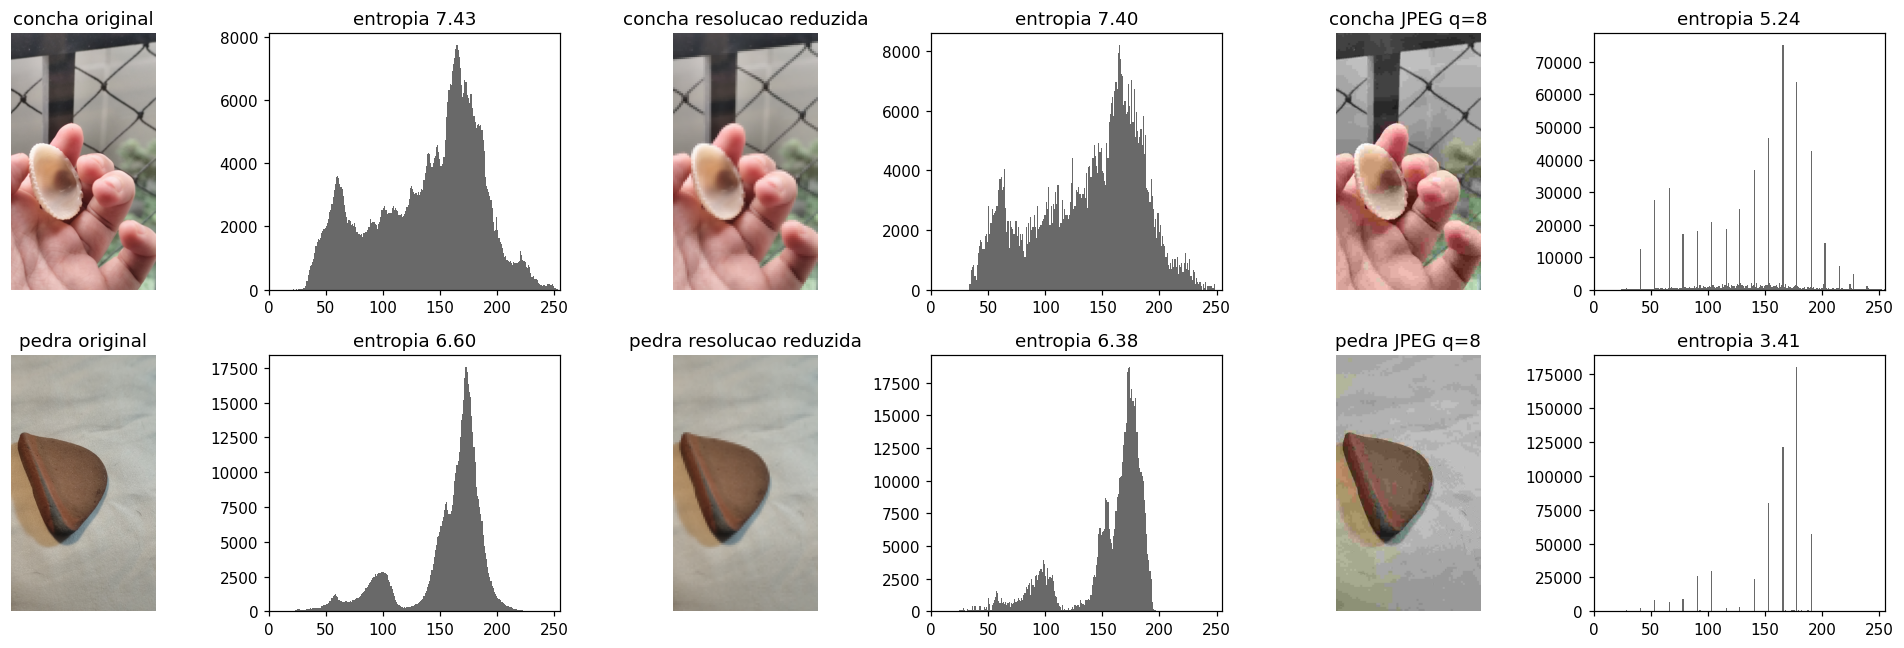

,classe,versao,entropia
0,concha,original,7.427
1,concha,resolucao reduzida,7.395
2,concha,JPEG q=8,5.236
3,pedra,original,6.599
4,pedra,resolucao reduzida,6.379
5,pedra,JPEG q=8,3.407


In [ ]:
def reduzir_resolucao(rgb, fator=8):
    h, w = rgb.shape[:2]
    pequena = cv2.resize(rgb, (w // fator, h // fator), interpolation=cv2.INTER_AREA)
    return cv2.resize(pequena, (w, h), interpolation=cv2.INTER_NEAREST)


def recomprimir_jpeg(rgb, qualidade=8):
    ok, buf = cv2.imencode('.jpg', cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR),
                           [cv2.IMWRITE_JPEG_QUALITY, qualidade])
    return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)


derivadas = {'concha': 3, 'pedra': 1}
linhas_ent = []

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for lin, (c, n) in enumerate(derivadas.items()):
    base = reduzir(carregar_rgb(caminho(c, n)))
    versoes = {
        'original': base,
        'resolucao reduzida': reduzir_resolucao(base),
        'JPEG q=8': recomprimir_jpeg(base),
    }
    for col, (nome, img) in enumerate(versoes.items()):
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        ent = shannon_entropy(g)
        linhas_ent.append({'classe': c, 'versao': nome, 'entropia': round(ent, 3)})
        axes[lin, col * 2].imshow(img)
        axes[lin, col * 2].set_title(f'{c} {nome}')
        axes[lin, col * 2].axis('off')
        axes[lin, col * 2 + 1].hist(g.ravel(), bins=256, range=(0, 255), color='dimgray')
        axes[lin, col * 2 + 1].set_title(f'entropia {ent:.2f}')
        axes[lin, col * 2 + 1].set_xlim(0, 255)
plt.tight_layout()
plt.show()

pd.DataFrame(linhas_ent)

**O histograma mudou muito?** A forma geral se mantém nas duas derivadas, os picos principais
continuam onde estavam. A diferença forte está no JPEG de qualidade baixa: ele cria blocos de cor
uniforme que concentram pixels em menos valores e deixam o histograma com aspecto penteado, com
picos isolados e vales entre eles. A redução de resolução mexe bem menos no formato do histograma.

**A entropia caiu ou aumentou?** Caiu nas duas derivadas, mas de formas bem diferentes. Reduzir a
resolução e recompor quase não alterou a entropia (a da concha foi de cerca de 7,43 para 7,40). Já
o JPEG com qualidade 8 derrubou a entropia de forma acentuada (a concha caiu para perto de 5,24 e
a pedra para 3,41), porque a compressão agrupa blocos inteiros em poucas cores e descarta muita
informação fina.

**Houve perda perceptível de informação útil?** Sim, principalmente no JPEG e principalmente na
textura. As costelas finas da concha e o grão da pedra perdem definição, que é justamente o traço
mais discriminativo. Para a estatística global a perda parece pequena, mas para os descritores
locais e de textura, que vivem do detalhe fino, ela é grande. Isso antecipa o que aparece no teste
de robustez da Parte 3.4.

## Parte 3: Análise local, pontos de interesse, descritores e matching

### 3.1 Pontos de interesse: cantos Shi-Tomasi e blobs

Detecto cantos com Shi-Tomasi (`cv2.goodFeaturesToTrack`) em uma imagem de cada classe. Cantos
são pontos onde a intensidade muda em mais de uma direção, então tendem a cair sobre quinas e
cruzamentos de bordas.

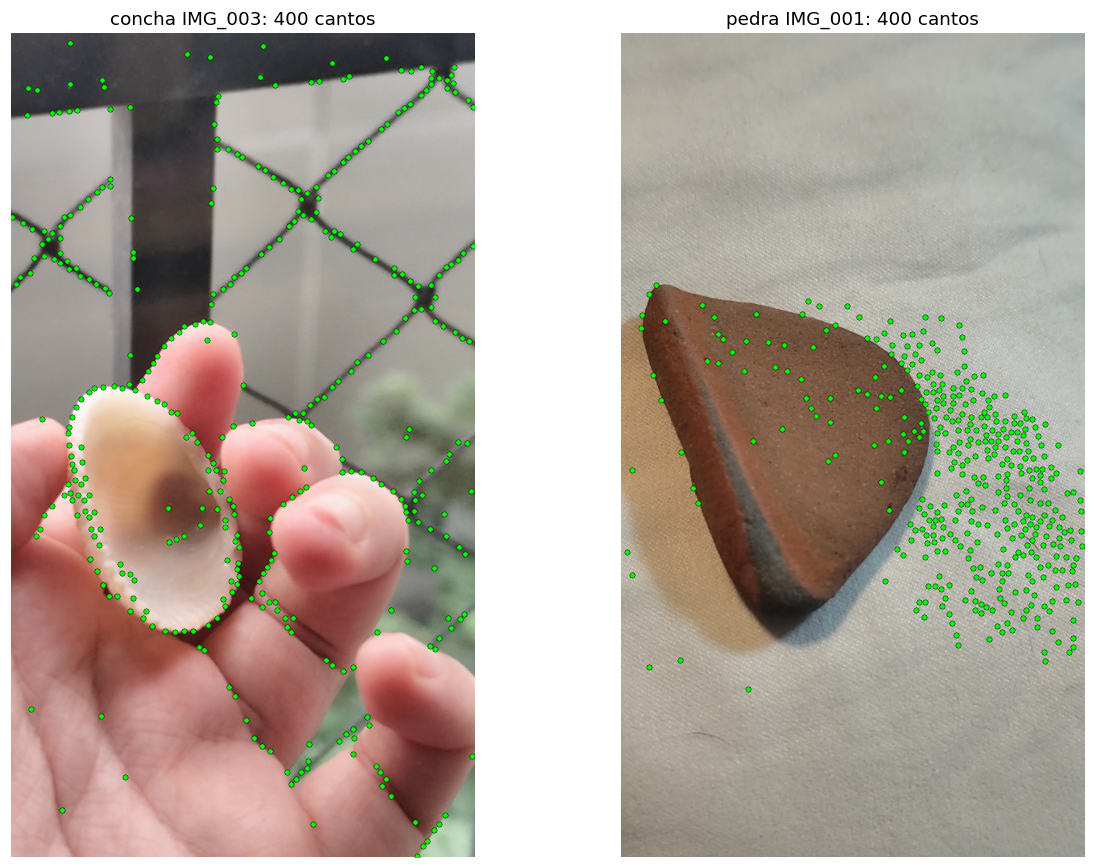

In [ ]:
def shi_tomasi(gray, max_cantos=400):
    cantos = cv2.goodFeaturesToTrack(gray, maxCorners=max_cantos,
                                     qualityLevel=0.01, minDistance=8)
    return cantos.reshape(-1, 2) if cantos is not None else np.empty((0, 2))


alvos = {'concha': 3, 'pedra': 1}
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, (c, n) in zip(axes, alvos.items()):
    rgb = reduzir(carregar_rgb(caminho(c, n)))
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    pts = shi_tomasi(gray)
    ax.imshow(rgb)
    ax.scatter(pts[:, 0], pts[:, 1], s=12, c='lime', edgecolors='black', linewidths=0.3)
    ax.set_title(f'{c} IMG_{n:03d}: {len(pts)} cantos')
    ax.axis('off')
plt.tight_layout()
plt.show()

Agora detecção de blobs com `blob_log` (Laplaciano do Gaussiano) em uma imagem adicional da
concha. Blobs são regiões aproximadamente circulares mais claras ou mais escuras que a vizinhança.

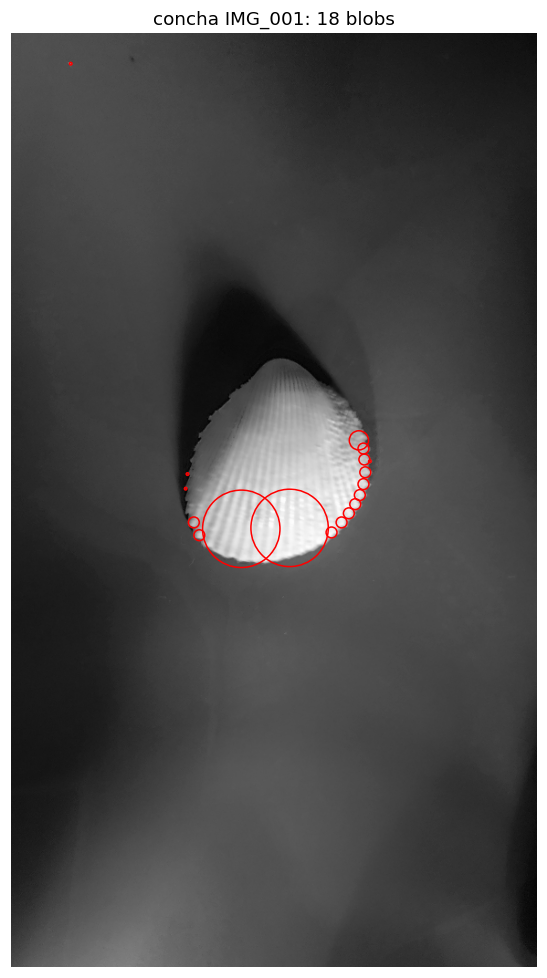

In [ ]:
gray = reduzir(carregar_gray(caminho('concha', 1)))
blobs = blob_log(gray.astype(float) / 255.0, max_sigma=30, num_sigma=10, threshold=0.10)
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

fig, ax = plt.subplots(figsize=(6, 9))
ax.imshow(gray)
for y, x, r in blobs:
    ax.add_patch(plt.Circle((x, y), r, color='red', fill=False, linewidth=1))
ax.set_title(f'concha IMG_001: {len(blobs)} blobs')
ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretação dos pontos de interesse.** Com o limite de 400 cantos, as duas imagens atingiram
o teto, então a contagem bruta não diferencia as classes. A distribuição revela um problema
importante: boa parte dos cantos cai no fundo, não no objeto. Na imagem da concha o detector
dispara fortemente sobre a tela de alambrado atrás do objeto, e na imagem da pedra sobre a trama
do tecido. Sobre os objetos em si, a concha rende cantos estruturados ao longo da borda serrilhada
e das costelas, enquanto a pedra rende cantos quase só no contorno. A lição é a mesma da análise
global: sem segmentar o objeto antes, o detector local mistura objeto e cena, e fundos texturizados
consomem parte dos pontos de interesse. Para este dataset, os cantos só seriam realmente
discriminativos depois de isolar o objeto do fundo.

O `blob_log` foi pouco informativo aqui. Ele procura manchas circulares de escala definida, e nem
a concha nem a pedra são compostas por manchas desse tipo: a concha é feita de linhas finas e
alongadas, não de bolhas, e a pedra é uma superfície contínua. Os poucos blobs detectados caem em
reflexos e na silhueta. Para este dataset o detector de cantos é mais adequado que o de blobs.

### 3.2 e 3.3 Descritores ORB e matching

Extraio keypoints e descritores ORB de três pares: dois pares de mesma classe (concha com concha,
pedra com pedra) e um par de classes diferentes (concha com pedra). O ORB usa descritores
binários, então o casamento é feito com `BFMatcher` e distância de Hamming, que conta bits
diferentes entre dois descritores.

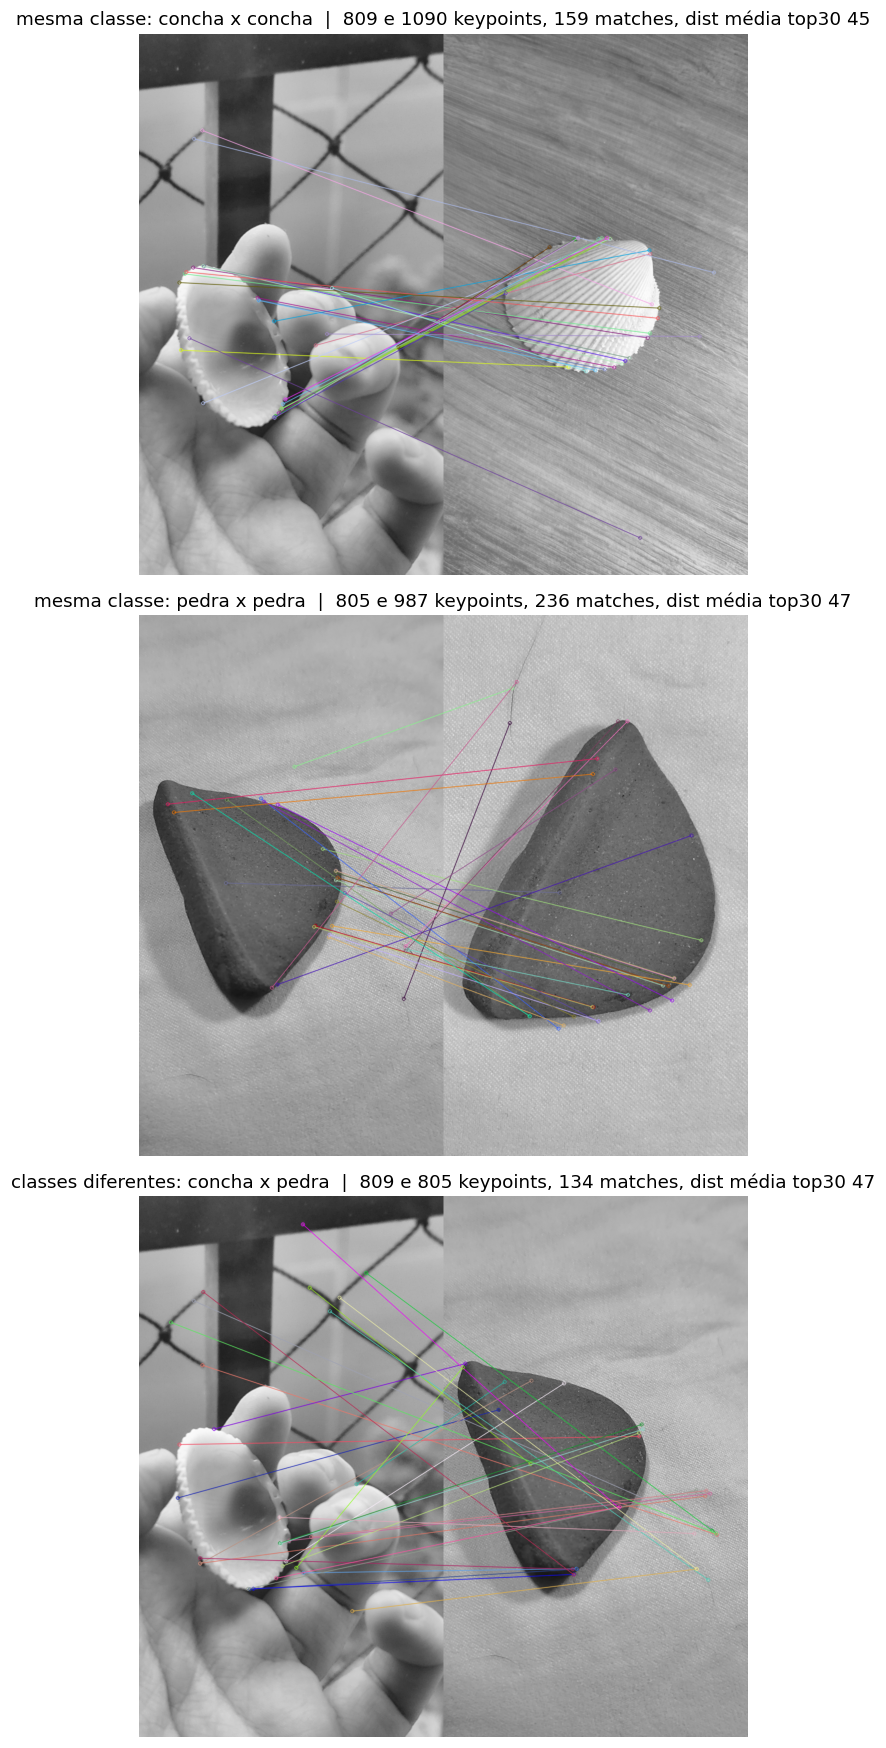

,par,kp_A,kp_B,matches,dist_media_top30
0,mesma classe: concha x concha,809,1090,159,44.6
1,mesma classe: pedra x pedra,805,987,236,46.6
2,classes diferentes: concha x pedra,809,805,134,47.0


In [ ]:
orb = cv2.ORB_create(nfeatures=1500)


def kp_desc(c, n):
    gray = reduzir(carregar_gray(caminho(c, n)))
    kp, des = orb.detectAndCompute(gray, None)
    return gray, kp, des


def casar(desA, desB):
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desA, desB)
    return sorted(matches, key=lambda m: m.distance)


pares = [
    ('mesma classe: concha x concha', ('concha', 3), ('concha', 4)),
    ('mesma classe: pedra x pedra', ('pedra', 1), ('pedra', 2)),
    ('classes diferentes: concha x pedra', ('concha', 3), ('pedra', 1)),
]

resumo_match = []
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
for ax, (titulo, a, b) in zip(axes, pares):
    gA, kpA, desA = kp_desc(*a)
    gB, kpB, desB = kp_desc(*b)
    matches = casar(desA, desB)
    top = matches[:30]
    dist_media = np.mean([m.distance for m in top])
    resumo_match.append({
        'par': titulo,
        'kp_A': len(kpA), 'kp_B': len(kpB),
        'matches': len(matches),
        'dist_media_top30': round(dist_media, 1),
    })
    vis = cv2.drawMatches(gA, kpA, gB, kpB, top, None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(vis)
    ax.set_title(f'{titulo}  |  {len(kpA)} e {len(kpB)} keypoints, '
                 f'{len(matches)} matches, dist média top30 {dist_media:.0f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

pd.DataFrame(resumo_match)

**Quantidade de keypoints.** O ORB detectou números parecidos nas duas classes, por volta de 800
a 1100 keypoints por imagem. Como nos cantos, a contagem sozinha não separa concha de pedra: o
teto de `nfeatures` e a densidade de bordas das duas superfícies acabam gerando totais próximos.

**Houve mais correspondências úteis na mesma classe?** O sinal existe, mas é fraco. A distância de
Hamming média dos 30 melhores matches ficou um pouco menor nos pares de mesma classe (cerca de 45
a 47) do que no par de classes diferentes (cerca de 47), o que indica descritores apenas
ligeiramente mais parecidos dentro da classe. O `crossCheck=True` já descarta correspondências que
não são mútuas, então a margem pequena é real, não ruído de pareamento.

**Quantidade significou qualidade?** Não. O par pedra com pedra teve mais matches (236) que o par
concha com concha (159), só porque os dois patches de pedra são mais parecidos entre si, e não
porque o casamento seja melhor. O par de classes diferentes teve a menor contagem e a maior
distância, o que é coerente, mas a diferença entre os dois pares de mesma classe mostra que o
número bruto de matches não mede qualidade.

**O que atrapalhou.** Diferenças de escala e de ângulo entre as fotos, fundos distintos e
iluminação desigual. Parte dos matches cai no fundo e não no objeto. No conjunto, o ORB separou as
classes apenas de forma sutil neste dataset, abaixo do que a textura conseguiria mostrar adiante.

### 3.4 Qualidade do matching: ratio test de Lowe

O `crossCheck` garante reciprocidade, mas não filtra ambiguidade. Refaço o matching com `knnMatch`
e o ratio test de Lowe, que mantém um match só quando o vizinho mais próximo é bem mais próximo
que o segundo. Esse é o filtro de qualidade correto para comparar imagens diferentes.

In [ ]:
def matching_ratio(a, b, ratio=0.75):
    gA, kpA, desA = kp_desc(*a)
    gB, kpB, desB = kp_desc(*b)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    bons = [m for m, n in bf.knnMatch(desA, desB, k=2) if m.distance < ratio * n.distance]
    dist = round(float(np.mean([m.distance for m in bons])), 1) if bons else 0.0
    return {'apos_ratio': len(bons), 'dist_media': dist}


linhas_q = []
for titulo, a, b in pares:
    d = {'par': titulo}
    d.update(matching_ratio(a, b))
    linhas_q.append(d)

pd.DataFrame(linhas_q)

,par,apos_ratio,dist_media
0,mesma classe: concha x concha,13,45.8
1,mesma classe: pedra x pedra,5,42.0
2,classes diferentes: concha x pedra,14,47.4


**Quantidade não significou qualidade, e o porquê é conceitual.** Mesmo após o ratio test a
contagem de bons matches continua baixa e não separa de forma confiável as classes: o par de
classes diferentes chega a ter tantos bons matches quanto os de mesma classe. A razão é importante
e vale registrar: os pares são objetos físicos diferentes, não duas vistas da mesma cena, então não
existe uma correspondência ponto a ponto verdadeira a ser recuperada. O ORB casa trechos de textura
parecidos onde eles existirem, inclusive entre uma concha e uma pedra. Por isso, deliberadamente
não aplico aqui uma verificação por homografia: ela só faz sentido entre duas imagens da mesma
cena, o que é exatamente o caso do teste de robustez a seguir. A conclusão honesta é que o matching
ORB par a par entre objetos distintos é frágil para classificar este dataset.

### 3.5 Teste de robustez

A partir de uma concha aplico três transformações: rotação leve, redução de contraste e
borramento. Para cada versão repito ORB mais matching contra a imagem original e observo quanto a
correspondência se degrada.

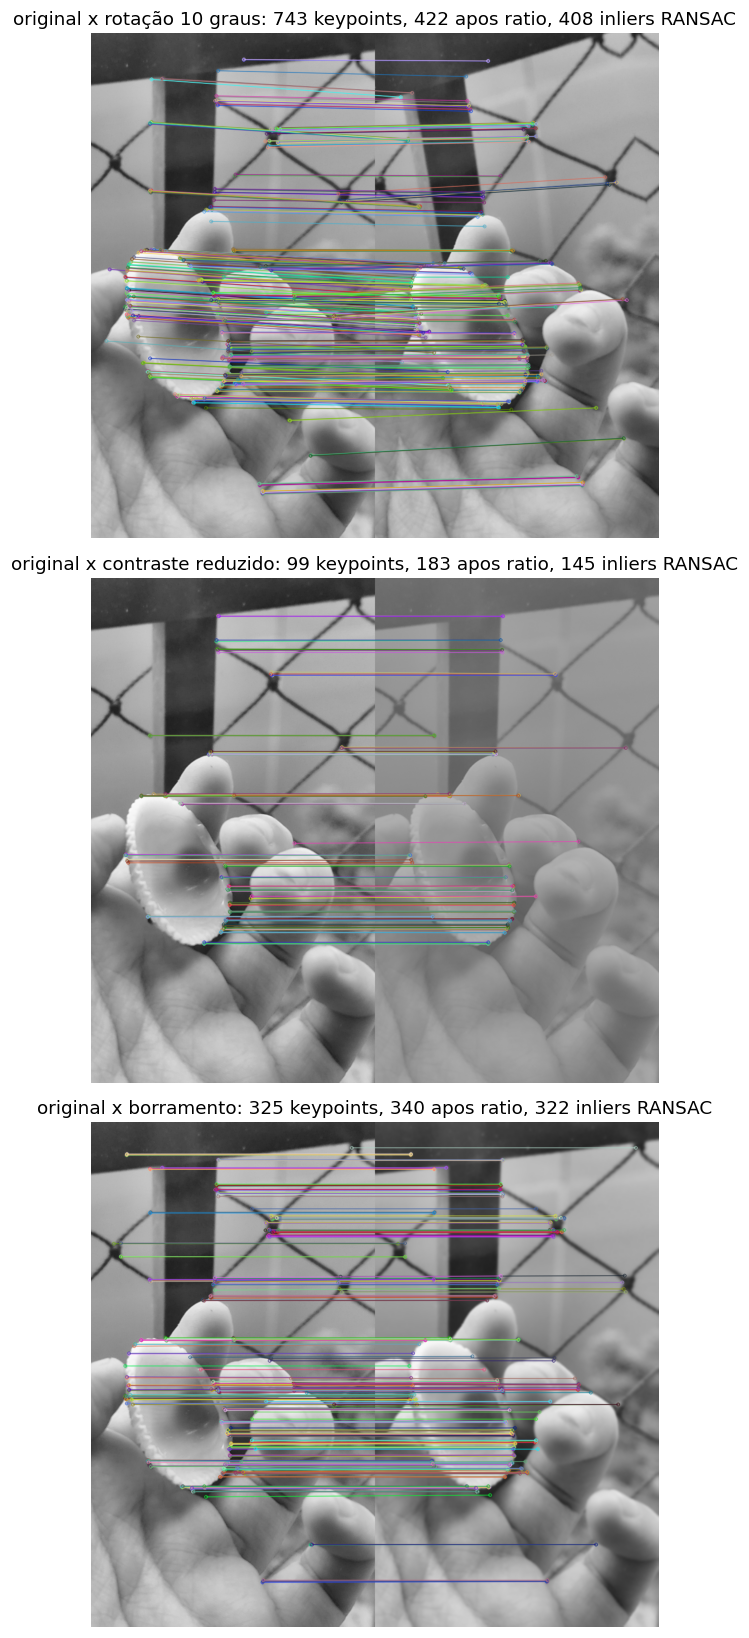

,versao,keypoints,apos_ratio,inliers_ransac,taxa_inliers
0,original,809,-,-,-
1,rotação 10 graus,743,422,408,0.97
2,contraste reduzido,99,183,145,0.79
3,borramento,325,340,322,0.95


In [ ]:
def rotacionar(gray, ang=10):
    h, w = gray.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
    return cv2.warpAffine(gray, M, (w, h), borderMode=cv2.BORDER_REFLECT)


def reduzir_contraste(gray, fator=0.4):
    m = gray.mean()
    return np.clip((gray.astype(float) - m) * fator + m, 0, 255).astype(np.uint8)


def borrar(gray, k=9):
    return cv2.GaussianBlur(gray, (k, k), 0)


base = reduzir(carregar_gray(caminho('concha', 3)))
kp0, des0 = orb.detectAndCompute(base, None)

transformacoes = {
    'rotação 10 graus': rotacionar(base),
    'contraste reduzido': reduzir_contraste(base),
    'borramento': borrar(base),
}

resumo_rob = [{'versao': 'original', 'keypoints': len(kp0),
               'apos_ratio': '-', 'inliers_ransac': '-', 'taxa_inliers': '-'}]
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
for ax, (nome, mod) in zip(axes, transformacoes.items()):
    kpm, desm = orb.detectAndCompute(mod, None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    bons = [m for m, n in bf.knnMatch(des0, desm, k=2) if m.distance < 0.75 * n.distance]
    mask = None
    if len(bons) >= 4:
        src = np.float32([kp0[m.queryIdx].pt for m in bons]).reshape(-1, 1, 2)
        dst = np.float32([kpm[m.trainIdx].pt for m in bons]).reshape(-1, 1, 2)
        _, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(mask.sum()) if mask is not None else 0
    taxa = round(inliers / len(bons), 2) if bons else 0.0
    resumo_rob.append({'versao': nome, 'keypoints': len(kpm), 'apos_ratio': len(bons),
                       'inliers_ransac': inliers, 'taxa_inliers': taxa})
    desenho_mask = mask.ravel().tolist() if mask is not None else None
    vis = cv2.drawMatches(base, kp0, mod, kpm, bons, None, matchesMask=desenho_mask,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(vis)
    ax.set_title(f'original x {nome}: {len(kpm)} keypoints, '
                 f'{len(bons)} apos ratio, {inliers} inliers RANSAC')
    ax.axis('off')
plt.tight_layout()
plt.show()

pd.DataFrame(resumo_rob)

Aqui a verificação por homografia é legítima, porque as duas imagens são a mesma cena, uma sendo
a transformação da outra. Por isso meço, além dos keypoints, quantos bons matches o RANSAC aceita
como geometricamente consistentes (inliers) e a taxa de inliers.

**O número de keypoints mudou?** Mudou bastante. A rotação preservou quase todos os pontos (de 809
para cerca de 743), confirmando a invariância do ORB a rotação. O borramento reduziu para perto de
325. A redução de contraste foi a mais severa, derrubando para cerca de 99, porque bordas mais
fracas deixam de passar do limiar do detector. Como sobram poucos pontos na versão de baixo
contraste, vários keypoints da original acabam casando com esses mesmos sobreviventes, por isso a
contagem de bons matches dessa versão parece alta mas está concentrada em poucos destinos.

**A qualidade dos matches caiu?** Não, e este é o ponto forte do ORB. Em todas as três versões o
RANSAC recupera a transformação correta com taxa de inliers alta, de cerca de 0,79 na versão de
baixo contraste a 0,97 na rotacionada. Ou seja, os matches que sobrevivem são geometricamente
coerentes: o ORB sabe alinhar a imagem com a sua versão transformada mesmo quando perde pontos.
Compare com a Parte 3.4, onde entre objetos físicos diferentes não havia geometria a recuperar.

**Até onde o descritor local foi robusto?** Bastante robusto quando existe uma relação geométrica
real entre as imagens: tolera rotação, borramento e queda de contraste sem perder a consistência
dos inliers. O que ele perde é quantidade de pontos, e a queda de contraste é a mais severa nesse
aspecto. Isso conecta com a Parte 2.3: processos que apagam o detalhe fino (baixo contraste,
desfoque, compressão forte, baixa resolução) reduzem os pontos estáveis disponíveis. A leitura
geral é que o ORB é uma ótima ferramenta de correspondência entre vistas do mesmo objeto, e uma
ferramenta fraca para classificar objetos diferentes, que era a tarefa deste dataset.

## Parte 4: Análise de textura, GLCM e LBP

### 4.1 Seleção das regiões

Em vez da imagem inteira, recorto um patch representativo da superfície de cada objeto, para que a
textura medida seja a do material e não a do fundo. Para a concha uso uma região central com as
costelas, e para a pedra uma região da superfície lisa.

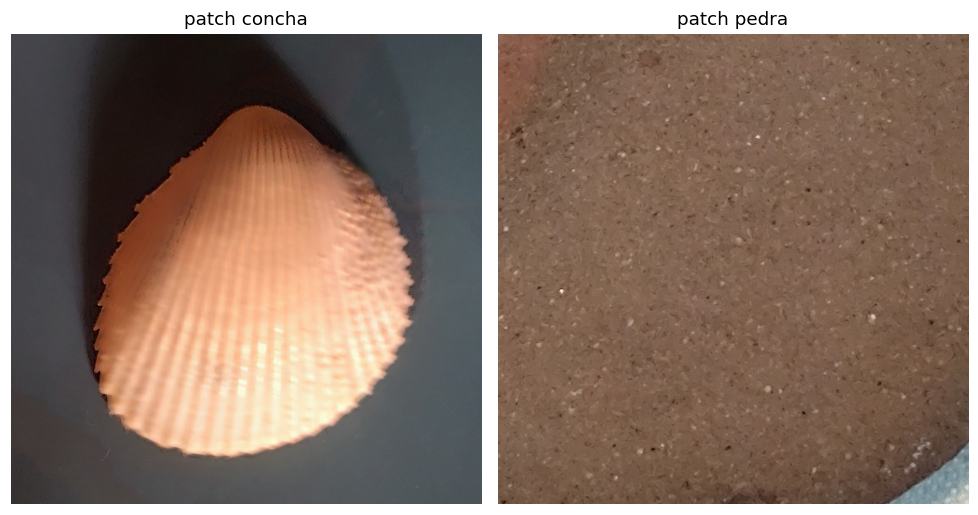

In [ ]:
def patch(rgb, cy, cx, raio):
    h, w = rgb.shape[:2]
    y, x = int(cy * h), int(cx * w)
    return rgb[y - raio:y + raio, x - raio:x + raio]


patches_rgb = {
    'concha': patch(carregar_rgb(caminho('concha', 1)), 0.45, 0.50, 600),
    'pedra': patch(carregar_rgb(caminho('pedra', 2)), 0.58, 0.58, 500),
}
patches_gray = {c: cv2.cvtColor(p, cv2.COLOR_RGB2GRAY) for c, p in patches_rgb.items()}

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax, c in zip(axes, CLASSES):
    ax.imshow(patches_rgb[c])
    ax.set_title(f'patch {c}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4.2 GLCM

Converto cada patch para tons de cinza e quantizo em 32 níveis para tornar a matriz de
coocorrência mais estável. Calculo a GLCM para a distância de 1 pixel em quatro ângulos (0, 45, 90
e 135 graus) e extraio contraste, homogeneidade, energia e correlação. O contraste cresce quando
vizinhos têm intensidades muito diferentes, a homogeneidade e a energia crescem em superfícies
uniformes, e a correlação mede o quanto a intensidade de um pixel prevê a do vizinho.

In [ ]:
def glcm_props(gray, niveis=32, distancias=(1,), angulos=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    q = (gray.astype(np.uint16) * niveis // 256).astype(np.uint8)
    g = graycomatrix(q, distances=list(distancias), angles=list(angulos),
                     levels=niveis, symmetric=True, normed=True)
    props = ['contrast', 'homogeneity', 'energy', 'correlation']
    return {p: float(graycoprops(g, p).mean()) for p in props}


linhas_glcm = []
for c in CLASSES:
    d = {'classe': c}
    d.update({k: round(v, 4) for k, v in glcm_props(patches_gray[c]).items()})
    linhas_glcm.append(d)

pd.DataFrame(linhas_glcm)

,classe,contrast,homogeneity,energy,correlation
0,concha,0.2713,0.8813,0.2116,0.9979
1,pedra,0.4181,0.8273,0.3694,0.9058


**Leitura da GLCM.** O resultado contraria a intuição inicial, e é instrutivo justamente por
isso. À distância de 1 pixel, o patch da pedra tem contraste mais alto (cerca de 0,42 contra 0,27),
energia mais alta (0,37 contra 0,21) e correlação mais baixa (0,91 contra 1,00) que o da concha. A
explicação está na escala de análise: as costelas da concha são ondulações suaves, então dois
pixels colados mudam pouco de intensidade (contraste baixo, correlação altíssima), enquanto a
superfície da pedra é granular, cheia de pontos de areia que fazem pixels vizinhos saltarem de
valor (contraste alto). A GLCM a 1 pixel está medindo o microgrão, não o desenho macroscópico das
costelas. Para captar o padrão das costelas seria preciso repetir a GLCM com distâncias maiores.
Ainda assim, as quatro propriedades separam claramente as duas classes, e foi a representação com a
diferença numérica mais nítida deste trabalho.

### 4.3 GLCM em múltiplas distâncias

A GLCM a 1 pixel mediu o microgrão. Para captar a estrutura macroscópica das costelas da concha,
repito a GLCM em distâncias crescentes (1, 3, 5, 10, 15, 20 pixels) e observo como contraste e
correlação evoluem. A expectativa é que a concha, por ter um padrão periódico de costelas, mostre
um comportamento diferente da pedra à medida que a distância cresce.

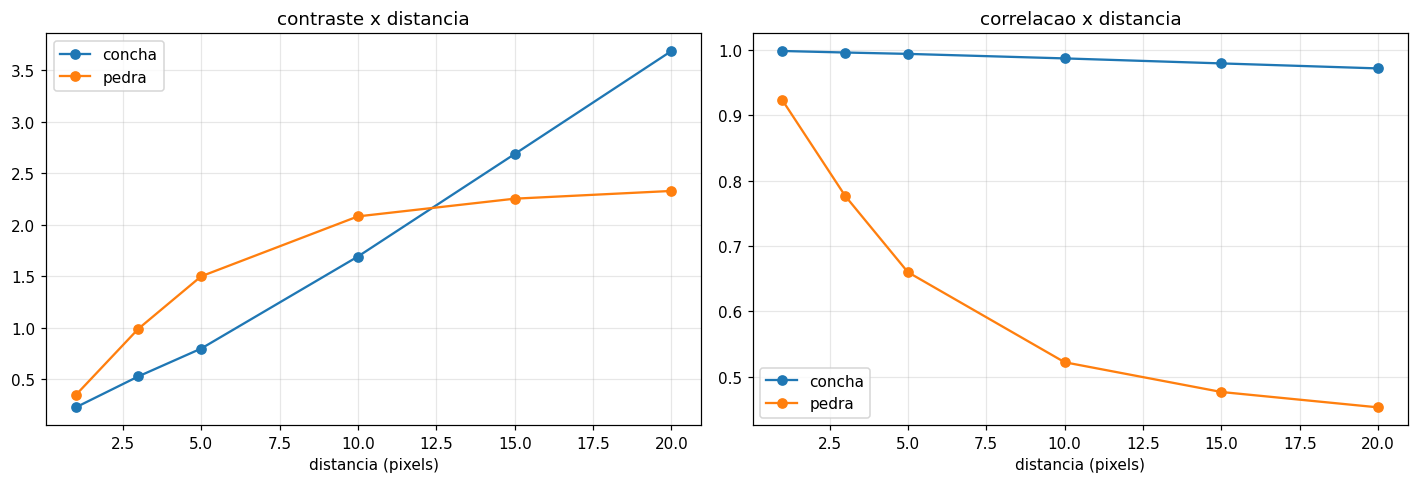

In [ ]:
distancias = [1, 3, 5, 10, 15, 20]


def glcm_curva(gray, niveis=32):
    q = (gray.astype(np.uint16) * niveis // 256).astype(np.uint8)
    g = graycomatrix(q, distances=distancias, angles=[0, np.pi/2],
                     levels=niveis, symmetric=True, normed=True)
    contraste = graycoprops(g, 'contrast').mean(axis=1)
    correl = graycoprops(g, 'correlation').mean(axis=1)
    return contraste, correl


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for c in CLASSES:
    cont, corr = glcm_curva(patches_gray[c])
    axes[0].plot(distancias, cont, marker='o', label=c)
    axes[1].plot(distancias, corr, marker='o', label=c)
axes[0].set_title('contraste x distancia')
axes[0].set_xlabel('distancia (pixels)')
axes[1].set_title('correlacao x distancia')
axes[1].set_xlabel('distancia (pixels)')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**O que a curva revela.** As duas classes trocam de posição conforme a distância aumenta, e essa
inversão é o achado mais informativo. Nas distâncias curtas a pedra tem mais contraste, por causa
do grão aleatório, mas o contraste dela satura cedo e a correlação despenca, porque dois pixels
afastados no grão deixam de se prever rapidamente. Na concha acontece o oposto: a correlação fica
perto de 1 mesmo a 20 pixels, e o contraste cresce de forma contínua até ultrapassar o da pedra por
volta de 12 pixels. Isso reflete a continuidade suave e periódica das costelas, que se mantêm
previsíveis ao longo do relevo e só acumulam diferença de intensidade em distâncias maiores. Ou
seja, a estrutura macroscópica que a GLCM a 1 pixel não enxergava aparece quando ampliamos a
distância. A escala de análise é decisiva, e a GLCM multiescala separa as classes por dois
mecanismos complementares, o microgrão nas distâncias curtas e a periodicidade das costelas nas
distâncias longas.

### 4.4 LBP

Calculo o Local Binary Pattern no modo `uniform`, que rotula cada pixel pelo padrão de vizinhança
ao seu redor, e monto o histograma normalizado dos padrões. O LBP é invariante a mudanças
monotônicas de iluminação, então descreve a microestrutura sem depender do brilho absoluto.

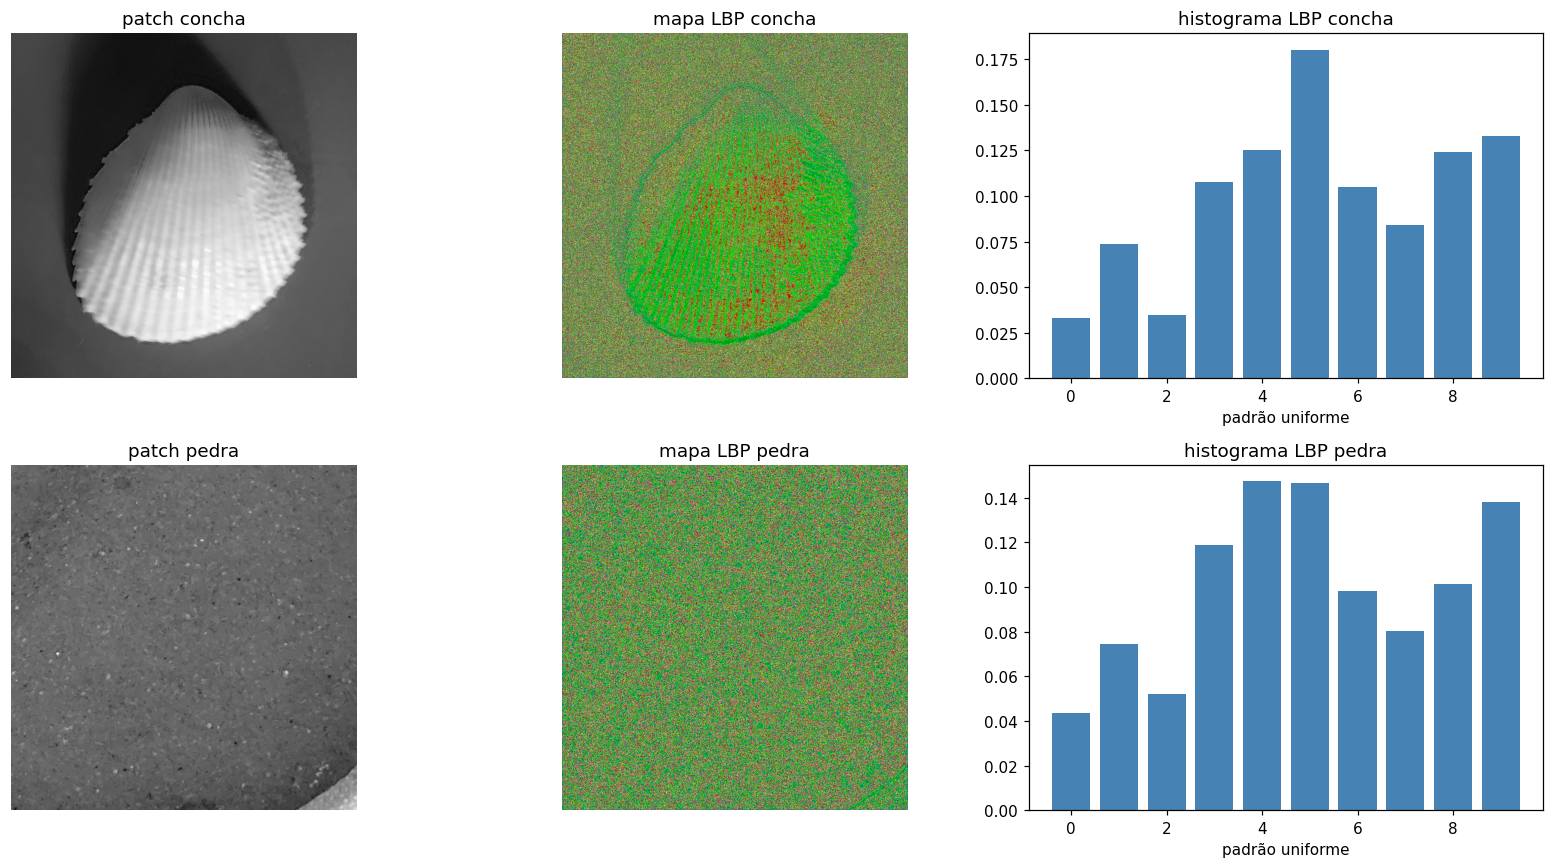

,concha,pedra
bin_0,0.033,0.043
bin_1,0.074,0.074
bin_2,0.035,0.052
bin_3,0.107,0.119
bin_4,0.125,0.147
bin_5,0.180,0.147
bin_6,0.105,0.098
bin_7,0.084,0.080
bin_8,0.124,0.101
bin_9,0.133,0.138


In [ ]:
P, R = 8, 1
n_bins = P + 2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_lbp = {}
for lin, c in enumerate(CLASSES):
    g = patches_gray[c]
    lbp = local_binary_pattern(g, P, R, method='uniform')
    h, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    hist_lbp[c] = h
    axes[lin, 0].imshow(g)
    axes[lin, 0].set_title(f'patch {c}')
    axes[lin, 0].axis('off')
    axes[lin, 1].imshow(lbp, cmap='nipy_spectral')
    axes[lin, 1].set_title(f'mapa LBP {c}')
    axes[lin, 1].axis('off')
    axes[lin, 2].bar(range(n_bins), h, color='steelblue')
    axes[lin, 2].set_title(f'histograma LBP {c}')
    axes[lin, 2].set_xlabel('padrão uniforme')
plt.tight_layout()
plt.show()

pd.DataFrame(hist_lbp, index=[f'bin_{i}' for i in range(n_bins)]).round(3)

**O LBP capturou microestruturas úteis?** Capturou, mas com poder de separação modesto neste
caso. Os dois histogramas têm formato parecido; as diferenças aparecem em poucos bins. O bin de
borda mais ativo pesa um pouco mais na concha, e alguns bins de transição suave pesam um pouco mais
na pedra. São diferenças reais, porém sutis.

**As classes ficaram mais separáveis por textura via LBP?** Menos do que via GLCM. O LBP com raio
1 também olha apenas a vizinhança imediata e, como a GLCM a 1 pixel, acaba misturando o microgrão
das duas superfícies, o que aproxima os histogramas em vez de afastá-los.

**GLCM e LBP foram coerentes entre si?** Sim, no sentido de que os dois descritores olham a
vizinhança imediata e, por isso, captam mais o grão fino que a estrutura macroscópica. A diferença
é que a GLCM resumiu essa informação em quatro números bem separáveis, enquanto o histograma LBP
ficou ambíguo. Entre os dois descritores de textura, a GLCM foi a mais discriminativa para este
dataset.

## Parte 5: Síntese integradora

Tabela comparativa final dos cinco tipos de descritor estudados:

In [ ]:
sintese = pd.DataFrame([
    {
        'Tipo de descritor': 'Histogramas',
        'O que representa': 'distribuição de intensidade e de cor da imagem inteira',
        'Vantagens': 'simples, rápido, bom para brilho e cor predominante',
        'Limitações': 'dominado por fundo e iluminação, ignora forma e textura',
        'Funcionou bem?': 'Não, muita sobreposição entre classes',
    },
    {
        'Tipo de descritor': 'Estatística global',
        'O que representa': 'média, variância, desvio e entropia da imagem',
        'Vantagens': 'resume contraste e informação em poucos números',
        'Limitações': 'mistura objeto e fundo, varia muito dentro da classe',
        'Funcionou bem?': 'Não, faixas das classes se sobrepõem',
    },
    {
        'Tipo de descritor': 'ORB + matching',
        'O que representa': 'pontos de interesse e descritores binários locais',
        'Vantagens': 'robusto a rotação, alinha vistas do mesmo objeto (RANSAC)',
        'Limitações': 'não classifica objetos diferentes, pega fundo texturizado',
        'Funcionou bem?': 'Parcial, ótimo para mesma cena, fraco entre objetos distintos',
    },
    {
        'Tipo de descritor': 'GLCM',
        'O que representa': 'relações espaciais de intensidade entre vizinhos',
        'Vantagens': 'resume a textura em poucas métricas bem separáveis',
        'Limitações': 'depende do patch, da quantização e da distância usada',
        'Funcionou bem?': 'Sim, foi a diferença numérica mais nítida',
    },
    {
        'Tipo de descritor': 'LBP',
        'O que representa': 'padrões binários locais da vizinhança de cada pixel',
        'Vantagens': 'invariante a iluminação, descreve microestrutura',
        'Limitações': 'a raio 1 mistura o microgrão das duas superfícies',
        'Funcionou bem?': 'Parcial, histogramas parecidos, diferenças sutis',
    },
])
sintese

,Tipo de descritor,O que representa,Vantagens,Limitações,Funcionou bem?
0,Histogramas,distribuição de intensidade e de cor da imagem...,"simples, rápido, bom para brilho e cor predomi...","dominado por fundo e iluminação, ignora forma ...","Não, muita sobreposição entre classes"
1,Estatística global,"média, variância, desvio e entropia da imagem",resume contraste e informação em poucos números,"mistura objeto e fundo, varia muito dentro da ...","Não, faixas das classes se sobrepõem"
2,ORB + matching,pontos de interesse e descritores binários locais,"robusto a rotação, alinha vistas do mesmo obje...","não classifica objetos diferentes, pega fundo ...","Parcial, ótimo para mesma cena, fraco entre ob..."
3,GLCM,relações espaciais de intensidade entre vizinhos,resume a textura em poucas métricas bem separá...,"depende do patch, da quantização e da distânci...","Sim, foi a diferença numérica mais nítida"
4,LBP,padrões binários locais da vizinhança de cada ...,"invariante a iluminação, descreve microestrutura",a raio 1 mistura o microgrão das duas superfícies,"Parcial, histogramas parecidos, diferenças sutis"


### Conclusão técnica

**1. Qual descritor foi mais útil?** A GLCM. Foi a representação que produziu a separação numérica
mais clara entre as classes (contraste, energia e correlação bem diferentes entre os patches),
ainda que numa direção contrária à intuição: a 1 pixel, a superfície granular da pedra tem mais
contraste que as costelas suaves da concha, e a GLCM multiescala mostrou que a periodicidade das
costelas aparece nas distâncias maiores. O ORB ficou em segundo plano para esta tarefa: o ratio
test mostrou que o matching par a par não separa objetos físicos diferentes de forma confiável, e
a verificação por RANSAC só foi legítima no teste de robustez, onde provou que o descritor alinha
muito bem vistas da mesma cena (taxa de inliers de 0,79 a 0,97). O LBP apontou diferenças sutis.

**2. Qual descritor foi menos útil?** Os descritores globais, histogramas e estatística da imagem
inteira. Eles são dominados pelo fundo e pela iluminação, que variam mais dentro de cada classe do
que entre as classes. A cor não ajudou porque as duas classes são de tons quentes parecidos, com o
vermelho dominante em ambas.

**3. Onde a aquisição influenciou fortemente?** Em tudo que é global, o brilho médio e o
histograma seguiram o fundo e a luz, não o objeto. Nos descritores locais e de textura a aquisição
pesou pela via da nitidez e da escala: a Parte 2.3 mostrou que comprimir em JPEG derruba a entropia,
a Parte 3.4 mostrou que borramento e baixo contraste destroem keypoints, e a Parte 4 mostrou que a
vizinhança de 1 pixel mede o microgrão e não a estrutura macroscópica. A escala de análise foi tão
decisiva quanto a escolha do descritor.

**4. O que eu usaria primeiro num sistema simples?** Montaria o vetor de características a partir da
textura: propriedades de GLCM em várias distâncias, para captar o grão fino e o padrão das costelas,
somadas ao histograma de LBP. Deixaria os histogramas globais de fora, ou no máximo como apoio, e
não usaria o matching ORB para classificar, já que ele não distingue objetos diferentes de forma
confiável; reservaria o ORB para tarefas onde ele é forte, como achar duplicatas ou alinhar duas
fotos do mesmo objeto. Antes de tudo, padronizaria a aquisição (mesma distância e foco) e
segmentaria o objeto do fundo, para que os descritores medissem o objeto e não a cena.

A hipótese inicial se confirmou em parte: a textura, sobretudo a GLCM, superou os descritores
globais, como eu esperava. O que eu não previa é que o ORB e o LBP ficariam apenas modestamente
acima dos globais, e que a própria GLCM separaria as classes numa direção oposta à que eu imaginava,
lembrando que o resultado depende muito da escala em que a textura é medida.